In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor

In [12]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [13]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
sc = StandardScaler()

target_column_nugget = "NuggetDiameter (mm)" 
target_column_class = "Category" 


x_train, y_train = get_features_and_target(train_df, target_column_nugget)
x_dev, y_dev = get_features_and_target(dev_df, target_column_nugget)


# Fit Nugget Estimator


In [14]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train)

# Predict on the test set
predictions_nugget_train = regressor.predict(x_train)
predictions_nugget_dev= regressor.predict(x_dev)


In [15]:
y_train

0      2.63
1      3.34
2      2.76
3      2.57
4      4.72
       ... 
290    3.58
291    3.44
292    4.35
293    3.58
294    3.50
Name: NuggetDiameter (mm), Length: 295, dtype: float64

In [16]:
predictions_nugget_train

array([2.6413379, 3.973597 , 2.683507 , 2.7150526, 4.091856 , 2.6489258,
       3.595269 , 2.682352 , 4.0461564, 2.6793032, 2.7906604, 2.6610904,
       2.6956367, 3.916206 , 3.7111793, 3.7187643, 2.6973155, 4.0762544,
       4.069511 , 4.0735564, 4.0395947, 4.060915 , 4.0760984, 4.0737286,
       4.0789022, 4.0552382, 4.0730796, 4.0646143, 4.0499167, 4.0649114,
       4.0752544, 3.9379754, 3.936605 , 3.7127695, 3.7478573, 3.7524114,
       3.6733074, 3.5081768, 3.4705586, 3.4821124, 3.4818332, 3.4601855,
       3.444871 , 3.449802 , 3.4410396, 3.444778 , 3.4756787, 3.3510962,
       3.3490453, 3.348771 , 3.3370254, 3.3465724, 3.341061 , 3.3421896,
       3.332669 , 3.334197 , 3.3420901, 3.335082 , 3.3264055, 3.3295908,
       3.3300457, 3.3315082, 3.3343792, 3.3365126, 3.3333259, 3.331419 ,
       3.3303308, 3.3314352, 3.332279 , 3.3330493, 3.333987 , 3.3321068,
       3.3405106, 3.3435879, 3.3539567, 3.3526764, 3.342393 , 3.3484516,
       3.3502808, 3.3470917, 3.3453908, 3.3438535, 

# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [17]:
def compute_interfacial_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     f_pull = 1 * (np.pi/4) * (nugget_prediction)**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1).iloc[0]
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((nugget_prediction) + 2*t)*t*365 
     return np.round(f_pull, 1) 

# Fit Model

In [18]:
# Target value

x_train, y_train = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [19]:
def compute_pullforces(x, y, predictions_class, predictions_nugget):
    pullforces = []

    for sample_id, pred, nugget_value in zip(y.index, predictions_class, predictions_nugget):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df, nugget_value)
        else:
            value = compute_pullout_failure(row_x_df, nugget_value)

        pullforces.append(value)

    return np.array(pullforces)


In [20]:
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train, predictions_nugget_train)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev, predictions_nugget_dev)


In [21]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()

In [22]:
print(pullforces_dev)

[5725.8        1400.5        5782.4        1402.69995117 6151.4
 1435.59997559 6149.9        1478.09997559 4046.4        3826.5
 3897.         3497.5        3557.9        3492.4        3401.2
 3429.2        3357.2        3404.6        3240.2        3425.6
 3354.5        3377.5        3289.5        3307.5        3330.
 3349.7        3281.5        3316.3        3272.8        3310.1
 3258.3        3274.1        3365.4        3365.2        3262.1
 3392.6        3406.4        3302.3        3333.         3367.4
 3304.5        3400.5        3381.8        3495.         3551.7
 3554.6        3586.6        3588.2        3497.4        3434.8
 3419.4        3403.5        3520.6        3505.4        3526.7
 3515.7        3535.7        3480.5        3513.1        3531.7
 3516.4        3465.2        3486.2        3387.7        3366.1
 3364.5        3330.2        3300.3        3318.9        3364.8
 3336.3        3442.8        3395.6        3397.1        3348.5
 3341.6        3379.         3330.5      

# Fit 2nd Model

In [23]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_Regressor)

# Predict on the test set
final_pred = regressor.predict(x_dev)

In [24]:
final_pred

array([4170.6094, 2147.6226, 4183.539 , 2147.9988, 5198.001 , 2247.6548,
       5150.5415, 2275.8022, 3338.912 , 3307.4614, 3323.2046, 2859.8506,
       2870.7544, 2861.5166, 2841.5583, 2845.353 , 2829.0354, 2845.9753,
       2734.582 , 2760.0825, 2740.755 , 2743.9438, 2734.1462, 2725.208 ,
       2732.8545, 2764.5293, 2738.727 , 2746.4873, 2744.2283, 2740.6206,
       2738.6406, 2737.606 , 2739.375 , 2741.2002, 2768.7627, 2777.7214,
       2777.1245, 2767.724 , 2754.9048, 2771.8396, 2769.1262, 2775.0776,
       2775.2925, 3106.0723, 3115.3354, 3118.0317, 3122.2124, 3121.454 ,
       3087.2866, 3074.1309, 3091.1072, 3087.0454, 3107.6287, 3053.227 ,
       3066.58  , 3060.1958, 3060.9238, 3045.0068, 3052.2034, 3054.1025,
       3059.5847, 3049.7832, 3050.669 , 2977.2   , 2974.2048, 2963.7983,
       2962.974 , 2948.1086, 2949.9773, 2961.6904, 2962.813 , 2973.7085,
       2964.2883, 2971.4338, 2965.742 , 2959.189 , 2956.5144, 2914.494 ,
       2922.9126, 2929.539 , 2926.0063, 2915.6565, 

In [25]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [26]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [27]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")


MAE:  126.26
RMSE: 219.93
R2: 0.62


# Cross Validation

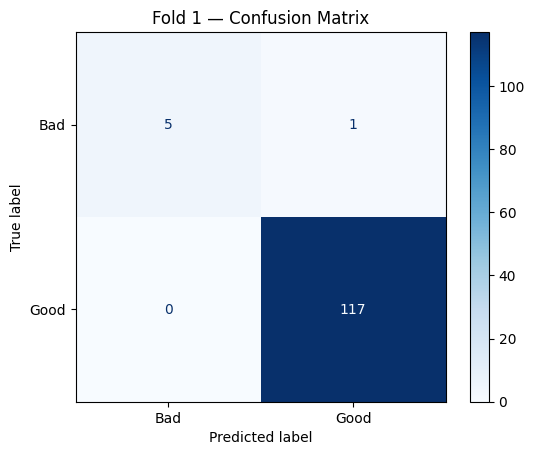

F1 Score: 0.622702434177844



=== Fold 1 ===
Direct:
 MAE=135.18,
 RMSE=236.61,
 R²=0.61

Hybrid:
 MAE=130.29,
 RMSE=234.39,
 R²=0.62
Pearson correlation (Physics vs True PullForce): 0.7772


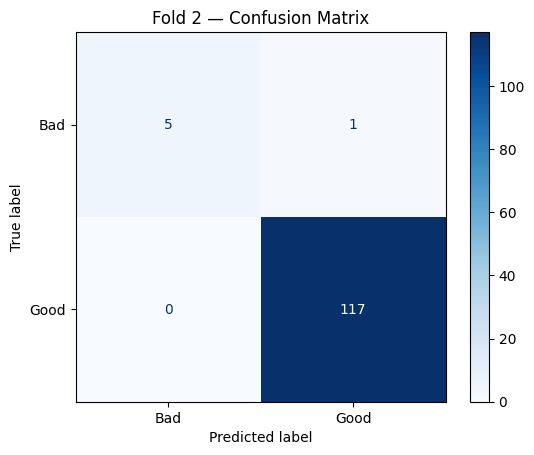

F1 Score: 0.6240179573512906



=== Fold 2 ===
Direct:
 MAE=134.05,
 RMSE=260.95,
 R²=0.69

Hybrid:
 MAE=134.09,
 RMSE=263.59,
 R²=0.68
Pearson correlation (Physics vs True PullForce): 0.7818


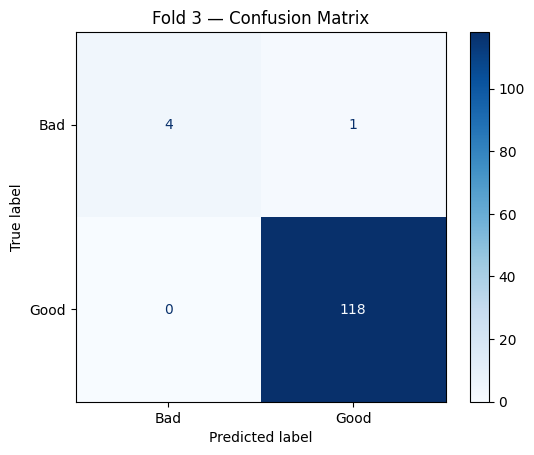

F1 Score: 0.6173847316704459



=== Fold 3 ===
Direct:
 MAE=132.30,
 RMSE=216.10,
 R²=0.68

Hybrid:
 MAE=130.86,
 RMSE=204.41,
 R²=0.72
Pearson correlation (Physics vs True PullForce): 0.8017

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
MAE mean: 133.84
RMSE mean: 237.89
R² mean: 0.66

--- Hybrid Model (Physics as Feature) ---
MAE mean: 131.74
RMSE mean: 234.13
R² mean: 0.67


In [28]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#Metrics with and without physical inference
direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):

    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    # Extract features for nugget, class, regression
    x_tr_nug, y_tr_nug = get_features_and_target(x_train, target_column_nugget)
    x_val_nug, y_val_nug = get_features_and_target(x_val, target_column_nugget)

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    #Nugget estimation
    regressor_nug = TabPFNRegressor()
    regressor_nug.fit(x_tr_nug,y_tr_nug)

    predictions_nugget_train = regressor_nug.predict(x_tr_nug)
    predictions_nugget_dev = regressor_nug.predict(x_val_nug)

    #Classification
    classifier = TabPFNClassifier()
    classifier.fit(x_tr_class, y_tr_class)

    predictions_class_train = classifier.predict(x_tr_class)
    predictions_class_dev = classifier.predict(x_val_class)

    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=predictions_class_dev,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )


    physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train, predictions_nugget_train) 
    physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev, predictions_nugget_dev)
    
    regressor = TabPFNRegressor()
    regressor.fit(x_tr_reg, y_tr_reg)

    # Predict on the test set
    predictions_regression_dev_without_physics = regressor.predict(x_val_reg)

    direct_mae.append(mean_absolute_error(y_val_reg, predictions_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, predictions_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, predictions_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=predictions_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category"
    )

    x_tr_hybrid = x_tr_reg.copy() 
    x_val_hybrid = x_val_reg.copy() 
    
    x_tr_hybrid["Physical_Inference"] = physics_train 
    x_val_hybrid["Physical_Inference"] = physics_val 
    
    hybrid_model = TabPFNRegressor() 
    hybrid_model.fit(x_tr_hybrid, y_train_reg) 
    
    hybrid_pred = hybrid_model.predict(x_val_hybrid) 
    hybrid_mae.append(mean_absolute_error(y_val_reg, hybrid_pred)) 
    hybrid_rmse.append(np.sqrt(mean_squared_error(y_val_reg, hybrid_pred))) 
    hybrid_r2.append(r2_score(y_val_reg, hybrid_pred))  

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=hybrid_pred,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category with Physical Inference"
    )

    print(f"\n=== Fold {fold+1} ===") 
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")
    print(f"Hybrid:\n MAE={hybrid_mae[-1]:.2f},\n RMSE={hybrid_rmse[-1]:.2f},\n R²={hybrid_r2[-1]:.2f}")

    corr = np.corrcoef(physics_train, y_train_reg)[0,1] 
    print(f"Pearson correlation (Physics vs True PullForce): {corr:.4f}")

print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"MAE mean: {np.mean(direct_mae):.2f}") 
print(f"RMSE mean: {np.mean(direct_rmse):.2f}") 
print(f"R² mean: {np.mean(direct_r2):.2f}")

print("\n--- Hybrid Model (Physics as Feature) ---") 
print(f"MAE mean: {np.mean(hybrid_mae):.2f}") 
print(f"RMSE mean: {np.mean(hybrid_rmse):.2f}") 
print(f"R² mean: {np.mean(hybrid_r2):.2f}") 

# Hyperparametertuning Nugget Regression

In [46]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model_name = "rf"  # or "xgbregressor"

def create_regressor(model_name, params):
    if model_name == "rf":
        return RandomForestRegressor(**params, random_state=42)
    elif model_name == "xgb":
        return XGBRegressor(
            **params,
            random_state=42,
            tree_method="hist",
            eval_metric="rmse"
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")



In [47]:
from scipy.stats import randint, uniform

param_spaces = {
    "rf": {
        "n_estimators": randint(50, 300),
        "max_depth": randint(3, 20),
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 10)
    },
    "xgb": {
          # Erster Durchlauf: randint(50, 300)
        'max_depth' : randint(1, 5),
        'learning_rate': randint(10, 31),  #Erster durchlauf: randint(1, 11)
        'n_estimators' : randint(1, 50),  

    }
}

In [48]:
def sample_params(space):
    params = {}
    for k, v in space.items():
        val = v.rvs()

        # Convert learning_rate integer → stepped float
        if k == "learning_rate":
            val = round(val / 100.0, 2)   # erster durchlauf: val = round(val / 10.0, 1) 1→0.1, 2→0.2, ..., 10→1.0

        params[k] = val
    return params


In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

def randomized_cv_search(model_name, cross_df, target_column, n_iter):
    space = param_spaces[model_name]

    best_rmse = float("inf")
    best_params = None
    best_model = None

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for i in range(n_iter):
        params = sample_params(space)
        print(f"\nTesting params: {params}")

        mae_list, rmse_list, r2_list = [], [], []

        for fold, (train_index, val_index) in enumerate(
                skf.split(cross_df["Sample ID"], cross_df["Category"])):

            train_df = cross_df.iloc[train_index].copy()
            val_df   = cross_df.iloc[val_index].copy()

            X_tr, y_tr = get_features_and_target(train_df, target_column)
            X_val, y_val = get_features_and_target(val_df, target_column)

            X_tr_scale = sc.fit_transform(X_tr)
            X_val_scale = sc.transform(X_val)

            model = create_regressor(model_name, params)
            model.fit(X_tr_scale, y_tr)

            preds = model.predict(X_val_scale)

            mae = mean_absolute_error(y_val, preds)
            rmse = np.sqrt(np.mean((y_val - preds)**2))
            r2 = r2_score(y_val, preds)

            mae_list.append(mae)
            rmse_list.append(rmse)
            r2_list.append(r2)

        rmse_mean = np.mean(rmse_list)
        print(f"RMSE={rmse_mean:.3f}")

        if rmse_mean < best_rmse:
            best_rmse = rmse_mean
            best_params = params
            best_model = model

    return best_model, best_params, best_rmse


In [50]:
best_model, best_params, best_rmse = randomized_cv_search(
    model_name=model_name,
    cross_df=cross_df,
    target_column="NuggetDiameter (mm)",
    n_iter=10000
)


Testing params: {'n_estimators': 205, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 1}
RMSE=0.319

Testing params: {'n_estimators': 109, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 8}
RMSE=0.314

Testing params: {'n_estimators': 223, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 3}
RMSE=0.314

Testing params: {'n_estimators': 228, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 3}
RMSE=0.315

Testing params: {'n_estimators': 222, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1}
RMSE=0.313

Testing params: {'n_estimators': 203, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 8}
RMSE=0.314

Testing params: {'n_estimators': 166, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 1}
RMSE=0.321

Testing params: {'n_estimators': 227, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 4}
RMSE=0.314

Testing params: {'n_estimators': 175, 'max_depth': 7, 'min_samples_split': 6, 'min_samples

In [ ]:
print("\n==============================")
print(" BEST MODEL FOUND ")
print("==============================")
print(f"Best RMSE:   {best_rmse:.2f}")
print(f"Best Params: {best_params}")


#==============================
# BEST MODEL FOUND XGBoost Nugget Estimation
#==============================
#Best RMSE:   0.31
#Best Params: {'max_depth': 3, 'learning_rate': 0.2, 'n_estimators': 10}


#==============================
# BEST MODEL FOUND Random Forest Nugget Estimation
#==============================
#Best RMSE:   0.31
#Best Params: {'n_estimators': 98, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 4}


 BEST MODEL FOUND 
Best RMSE:   0.3081794789457622
Best Params: {'n_estimators': 98, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 4}
